Selected Sentiment140 dataset because Twitter data is very  noisy and preprocessing techniques results will clear.

Part 1: Text Processing & Normalization

Task 1: Raw Text Cleaning

In [1]:
# Dataset Loading
import pandas as pd
file_path='/content/training.1600000.processed.noemoticon.csv'
df=pd.read_csv(file_path,encoding='latin-1',header=None,nrows=10000)
column_names=['target','ids','date','flag','user','raw_text']
df_neg=pd.read_csv(file_path,encoding='latin-1',header=None,names=column_names,nrows=50000)
df_pos=pd.read_csv(file_path,encoding='latin-1',header=None,names=column_names,skiprows=800000,nrows=50000)
# Combine and Shuffle
df=pd.concat([df_neg,df_pos]).sample(frac=1,random_state=42).reset_index(drop=True)
# Only require raw_text column and target column
df=df[['target','raw_text']]
print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,target,raw_text
0,4,"home from L&amp;L, would rather work at night,..."
1,4,@mr_billiam ooh...thanks for the tip. I'll do ...
2,0,"@belle_lulu site was hacked but thank you, I ..."
3,4,"back to repeating the climb by hannah montana,..."
4,4,@stunninwmylove 562 262 1736 call meeee mikey...


Here loading dataset for analysis and manipulation only 100000 rows for quick processing .It include 50000 postive and 50000 negative tweets to keep data  perfectly balance .

In [2]:
# Applying Preprocessing setps
import re
def clean_text(text):
  # Lowercasing
  text=text.lower()
  # Removing URLs and User Mentions(@user)
  text=re.sub(r'http\S+|www\S+|https\S+','',text,flags=re.MULTILINE)
  text=re.sub(r'@\w+','',text)
  # Removing Punctuation
  text=re.sub(r'[^\w\s]','',text)
  # Removing Numbers (Justification:Noise reduction)
  text=re.sub(r'\d+','',text)
  return text.strip()
# Applying Cleaning
df['cleaned_text']=df['raw_text'].apply(clean_text)
# Compare Original vs Cleaned
print("Compare Original vs Cleaned")
df[['raw_text','cleaned_text']].head(10)




Compare Original vs Cleaned


,raw_text,cleaned_text
0,"home from L&amp;L, would rather work at night,...",home from lampl would rather work at night muc...
1,@mr_billiam ooh...thanks for the tip. I'll do ...,oohthanks for the tip ill do that asap you are...
2,"@belle_lulu site was hacked but thank you, I ...",site was hacked but thank you i shall think o...
3,"back to repeating the climb by hannah montana,...",back to repeating the climb by hannah montana ...
4,@stunninwmylove 562 262 1736 call meeee mikey...,call meeee mikey wiznizzle
5,@NoodleRadio who won now bitch..you gave up,who won now bitchyou gave up
6,@sionnyn I feel creeeeeeam,i feel creeeeeeam
7,"Sammy, If your reading this. You are amazing. ...",sammy if your reading this you are amazing you...
8,@eriktheplaid I will have to check out TextMat...,i will have to check out textmate i have heard...
9,My brother is sick too lol. Quite weird,my brother is sick too lol quite weird


After applying cleaning on data now in standard format all alphabets in lower case(e.g Happy now happy) case normalization and get only one identity helps to Machine learning models learn accurately.Removed user mention and URL have no any impact on sentiment useless for model training .Removed punctions like  which reduce noise.And also removed numbers (dates and counts) often confuse model and increase vocabulary size have no important meanings.

Task 2: Tokenization & Stopwords


In [3]:
# Importing libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Downloding Essential components of NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
# English stopwords list
stop_words=set(stopwords.words('english'))
def tokenize_and_remove_stopwords(text):
  # Tokenization ( splitting sentence into list wo words)
  tokens=word_tokenize(text)
  # Stopword Removal:
  filtered_tokens=[word for word in tokens if word not in stop_words]
  return  tokens,filtered_tokens
# Applying on dataset
df['all_tokens']=df['cleaned_text'].apply(lambda x:tokenize_and_remove_stopwords(x)[0])
df['tokens_no_stop']=df['cleaned_text'].apply(lambda x:tokenize_and_remove_stopwords(x)[1])
# Result
print("TOKENIZATION & STOPWORDS")
df[['all_tokens','tokens_no_stop']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


TOKENIZATION & STOPWORDS


,all_tokens,tokens_no_stop
0,"[home, from, lampl, would, rather, work, at, n...","[home, lampl, would, rather, work, night, much..."
1,"[oohthanks, for, the, tip, ill, do, that, asap...","[oohthanks, tip, ill, asap, star]"
2,"[site, was, hacked, but, thank, you, i, shall,...","[site, hacked, thank, shall, think, area, im, ..."
3,"[back, to, repeating, the, climb, by, hannah, ...","[back, repeating, climb, hannah, montana, im, ..."
4,"[call, meeee, mikey, wiznizzle]","[call, meeee, mikey, wiznizzle]"


After tokenization sentences convert into  list of words and each word analyzed as single feature by model .By comparing before and after removing of stopwords can be see sentance length reduce become dense and short and also reduce size of vocabulary (remove noise and remain important words) it helps model to focus on sentiment-rich words and not get confuse by (e.g is ,the words) training become fast and accurate.

Identified:
Words that might be wrongly removed

By removing stopwords (e.g no not from not happy ) can flip the meaning of sentence and lead to missclassification model will consider Negative tweet as Postive tweet called negation.Sometime people share feelings with personal touch (I,We) by removing these stopwords can break personal connection of feelings called.And meaningful Conjunctions (e.g but) by removing this type of stoping words contradiction of words will not be understand by model.


Task 3 : Stemming vs Lemmatization


In [4]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
# downloding Wordnet and Omw (for Lemmatization)
nltk.download('wordnet')
nltk.download('omw-1.4')
stemmer=PorterStemmer()
lemmatizer=WordNetLemmatizer()
def apply_stemm_and_lemma(tokens):
  # Stemming quickly cut the words
  stems=[stemmer.stem(w) for w in tokens]
  # Lemmatization look for dictionary root
  lemmas=[lemmatizer.lemmatize(w,pos='v') for w in tokens]
  return stems,lemmas
# Applyging on dataset
results=df['tokens_no_stop'].apply(apply_stemm_and_lemma)
# Saving in seperate columns
df['stems']=results.apply (lambda x:x[0])
df['lemmas']=results.apply (lambda x:x[1])
# Comparing output differece & Linguistic Correctness
print("COMPERISON")
df[['tokens_no_stop','stems','lemmas']].head()




[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


COMPERISON


,tokens_no_stop,stems,lemmas
0,"[home, lampl, would, rather, work, night, much...","[home, lampl, would, rather, work, night, much...","[home, lampl, would, rather, work, night, much..."
1,"[oohthanks, tip, ill, asap, star]","[oohthank, tip, ill, asap, star]","[oohthanks, tip, ill, asap, star]"
2,"[site, hacked, thank, shall, think, area, im, ...","[site, hack, thank, shall, think, area, im, ac...","[site, hack, thank, shall, think, area, im, ac..."
3,"[back, repeating, climb, hannah, montana, im, ...","[back, repeat, climb, hannah, montana, im, don...","[back, repeat, climb, hannah, montana, im, do,..."
4,"[call, meeee, mikey, wiznizzle]","[call, meeee, mikey, wiznizzl]","[call, meeee, mikey, wiznizzle]"


Stemming chop/cut suffixes from the end of words (e.g inspiration to inspire ) .Lemmatization  find dictionary root and check complete words ( e.g it keep inspiration to inspiration because that is actual word) .


There is no linguistic correctness in stemming it's purpose is only reduce size of word despite of it remain as meaningful word or not (e.g inspir).

Lemmatization 100% linguistically correct it always provide a number present in dictionary and keep meaning.


Reflection: which method is better for:

Search Engines:

For search engines speed and high recall if someone search "Fishing" and if provide "Fish", "Fisher" results it will also acceptable stemming is fast because does not require to check dictionary only need to chop suffixes.




Chatbots:

For chatbots ( Alexa ,Customer Support bots) important is Lemmatization chatbots need to speak human like langauge if chatbots write (e.g happi) will not understand by humans  here correctness and meanings are essential.


Text classification:

For text classification  (sentiment andlysis ) need correct  sense of word.Stemming can convert words with different meanings into same meanings(Caring and Car both become car ) model will get confuse.Lemmatization keep words or features meaningful and clean increase accuracy.



Part 2 : Text Representation

Task 4 : N-gram Modeling


In [5]:
from nltk.util import ngrams
from collections  import Counter
all_words=[word for sublists in df['lemmas'] for word in sublists]
# Generating N-grams (relationship of words)
unigrams=list(ngrams(all_words,1))
bigrams=list(ngrams(all_words,2))
trigrams=list(ngrams(all_words,3))
# Identify Most Frequent N-grams
top_unigrams=Counter(unigrams).most_common(10)
top_bigrams=Counter(bigrams).most_common(10)
top_trigrams=Counter(trigrams).most_common(10)
# Top Unigrams
print("Top Unigrams")
print(top_unigrams)
# Top Bugrams
print("Top Bigrams")
print(top_bigrams)
# Top Trigrams
print("Top Trigrams")
print(top_trigrams)



Top Unigrams
[(('get',), 11272), (('go',), 10584), (('im',), 10440), (('work',), 6167), (('good',), 5774), (('day',), 5450), (('like',), 5023), (('today',), 4320), (('love',), 4274), (('time',), 4127)]
Top Bigrams
[(('gon', 'na'), 1302), (('wan', 'na'), 943), (('last', 'night'), 843), (('good', 'morning'), 793), (('cant', 'wait'), 757), (('im', 'go'), 608), (('feel', 'like'), 558), (('go', 'back'), 552), (('get', 'ta'), 551), (('look', 'forward'), 550)]
Top Trigrams
[(('im', 'gon', 'na'), 315), (('wan', 'na', 'go'), 268), (('dont', 'wan', 'na'), 190), (('cant', 'wait', 'see'), 126), (('dont', 'want', 'go'), 113), (('gon', 'na', 'go'), 113), (('get', 'ready', 'go'), 103), (('go', 'back', 'school'), 96), (('want', 'go', 'back'), 86), (('get', 'ready', 'work'), 77)]


Explain how context improves with higher N:

By analyzing can be see unigrams (no context )contain only one word (e.g get has no clear  meaning ) but in Bigrams (basic phrase) increase context (e.g good morning ) clean meaning it is a greeting.In Trigrams (N=3 ) provides  full intenet and emotions helps to understand complete meaning (e.g cant wait see ) shows a clear excitment so with higher  N  semantic meaning becomes much more clear helps model to understand relationship between words.


Task 5 : Vectorization Techniques

In [6]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
import pandas as pd
# Lemmas back join into sentences
df['final_text']=df['lemmas'].apply(lambda x :''.join(x))
corpus=df['final_text']
# Bag of Words (Count Vectorizer)
cv=CountVectorizer()
bow_matrix=cv.fit_transform(corpus)
# TF-IDF Vectorizer
tfidf_vectorizer=TfidfVectorizer()
tfidf_matrix=tfidf_vectorizer.fit_transform(corpus)
# Metrics Calculation Function
def calculate_metrics(matrix,Vectorizer):
  # Vocabulary Size
  vocab_size=len(Vectorizer.vocabulary_)
  # Sparsity (Zeros proportion)
  total_elements=matrix.shape[0]*matrix.shape[1]
  zero_elements=matrix.nnz
  sparsity=1.0-(zero_elements/total_elements)
  # Features Importances
  importance_scores=pd.DataFrame(matrix.toarray(),columns=Vectorizer.get_feature_names_out()).sum()
  return vocab_size,sparsity,importance_scores
# Metrics calculation
bow_vocab_size,bow_sparsity,bow_importance=calculate_metrics(bow_matrix,cv)
tfidf_vocab_size,tfidf_sparsity,tfidf_importance=calculate_metrics(tfidf_matrix,tfidf_vectorizer)
# Results Display
print(f"{'Metric'.ljust(20)} | {'Bag of Words'.ljust(15)} | {'TF-IDF'.ljust(15) }")
print(f"{'Vocabulary Size'.ljust(20)}| {str(bow_vocab_size).ljust(15)}| {str(tfidf_vocab_size).ljust(15) }")
print(f"{'Sparsity'.ljust(20)}| {format(bow_sparsity,'.4f')}| {format(tfidf_sparsity,'.4f')}")
print("Top 5 Features by importance")
print("BoW (Frequency)")
print(bow_importance.sort_values(ascending=False).head(5))
print("TF-IDF (Weights)")
print(tfidf_importance.sort_values(ascending=False).head(5))


Metric               | Bag of Words    | TF-IDF         
Vocabulary Size     | 95255          | 95255          
Sparsity            | 1.0000| 1.0000
Top 5 Features by importance
BoW (Frequency)
clean          286
thank          229
goodmorning     85
work            82
miss            53
dtype: int64
TF-IDF (Weights)
clean          286.0
thank          229.0
goodmorning     85.0
work            82.0
miss            53.0
dtype: float64


In both  BoW (bag of words ) and tf-idf(term-frequency -inverse document frequency ) vocabulary size same and sparsity  indicates a lot of space contains zero  in matrix represent each tweets cover only few words of entire dictionary.  

Reflection:
Why is TF-IDF usually better than BoW?

TF-IDF better than BoW  because focus on quality not on quantity it keep the words at top which are rare (meaningful words) helps model focus on actual information rather than frequent vocabulary and give the more weight to rare words.BoW prioritize  words based on their raw frequency it consider words appear with high count are more important but in actual these words confuse the model which are present frequently everywhere.

Part 3 : Word Embeddings


Task 6 : Create Embeddings


In [7]:
! pip install gensim

In [8]:
from gensim.models import Word2Vec
# Model Training
# Sentences(lemmas list),vector_size=representing each words in 100 dimension,window(previous and next 5 words context window,min_count (word appear at least 2-3 time) )
model=Word2Vec(sentences=df['lemmas'],vector_size=100,window=5,min_count=2,workers=4)
print("WORD2VEC Training complete")
# Tasks
# 1. Similar words
target_word='love'
if target_word in model.wv:
    similar_content=model.wv.most_similar(target_word,topn=5)
    print(f"Similar words to '{target_word}':")
    for word,similarity in similar_content:
        print(f"{word}:{similarity}")
else:
  print(f"'{target_word}' not found in the vocabulary")
# 2. Word Analogies
# Bad-Good+Happy=?
print(" Word Analogy : Bad - good +happy")
try:
    # positive=['Bad','Happy'] (add)
    # negative=['Good']        (substract)
    analogy_result=model.wv.most_similar(positive=['bad','happy'],negative=['good'],topn=1)
    print(f"Result:{analogy_result[0][0]} (Score : {analogy_result[0][1]:.4f})")
except KeyError as e :
  print(f"Analogy Error : {e} these words not found in the vocabulary")


WORD2VEC Training complete
Similar words to 'love':
rock:0.8111185431480408
lt:0.8027687072753906
amaze:0.8009124398231506
luv:0.797283947467804
osment:0.7882223129272461
 Word Analogy : Bad - good +happy
Result:crapy (Score : 0.6891)


From the above result can be see which words similar or near  to love (at same place in vector space) demonstrate model developed semantic understanding . and word analogy shows intelligence of model it has ability to identify or understand difference between happy and sicker as good and bad has understanding of happy and sad feelings.

Part 4 : Language Models


Task 8:
Build a Simple N-gram Language Model


In [9]:
import nltk
from nltk.util import ngrams
from collections import Counter,defaultdict
# Corpus(all tokens in a list)
all_tokens=[token for sublist in df['lemmas'] for token in sublist]
# Unigram model (single word frequency)
unigram_counts=Counter(all_tokens)
total_words=len(all_tokens)
# Bigram model (combination of two words)
bigrams=list(ngrams(all_tokens,2))
bigram_counts=Counter(bigrams)
# Bigram Probabilities (Dictionary structure)
model_bigram=defaultdict(lambda:defaultdict(int))
for (w1,w2 ),count in  bigram_counts.items():
  model_bigram[w1][w2]=count
# Tasks
# Predict Next word (Bigram)
def predict_next_word(sentence):
  input_tokens=sentence.lower().split()
  if not input_tokens:
    return "Sentence is empty"
  last_word=input_tokens[-1]

  if last_word in model_bigram:
    # word with high frequency will predict
    next_word=max(model_bigram[last_word],key=model_bigram[last_word].get)
    return next_word
  return "Word context not found"
# checking
test_sentence=' i love'
prediction=predict_next_word(test_sentence)
print("N-gram Language Model")
print(f" Input Sentence: '{test_sentence}'")
print(f" Bigram Prediction Next Word: '{prediction}'")
# Compare Unigram vs Bigram
print("Unigram vs Bigram Comparison")
most_common_unigram=unigram_counts.most_common(1)[0][0]
print(f"Unigram  Prediction (Global ): '{most_common_unigram}'")
print(f"Bigram Prediction (depend on context): '{prediction}'")




N-gram Language Model
 Input Sentence: ' i love'
 Bigram Prediction Next Word: 'u'
Unigram vs Bigram Comparison
Unigram  Prediction (Global ): 'get'
Bigram Prediction (depend on context): 'u'


unigram model predict 'get' which is most frequently appear in tweets for it context does not matter.
In Bigram calculate probability which word mostly appear with test word which word has highest probabilty predict as result.

Reflection:
Why so N-gram models fail on long sentences?

N-gram model fails on long sentences because it contains only one word memory (N-1) called short range dependency  as it move forward forgets what was previous word or on which topic sentence was started and it works on counting not on grammer so it provide results in long sentences have no sensible meaning.also get confuse on sequence which has not yet see in dataset has zero probability .

Task 9: Mini LLM Conceptual Design

Design a simple LLM pipeline from scratch:
Include


Tokenization:
(Breaking it down) Computers only understand numbers cannot read "A,B,C".Tokenization is process of chopping a sentence into smaller pieces(tokens) and assign or give each piece a unique ID Number.
how it works (Sentence "I love AI" becomes [101,452,890] unique id for each token).


Embedding layer ( Adding Meaning the map):
 An ID number like (452) does not tell computer what a word means.The Embedding Layer converts these IDs into vectors (a list of coordinates) .It place words on a Mental Map words with similar meanings like "Happy" and "Joyful" are placed very close to each other. Goal is to transform a simple number into "Concept" computer can visualize and understand in multi-demensional space.


Sequence modeling (RNN/Transformer Conceptually): "The Brain"

Recurrent Neural Network process words one by one read step by step often struggle with long range dependency forget the beginning of long sentence by the time they reach end.
Transformer(Self -Attention):

Modern approach instead of reading one by one looks at entire sentence simultaneously .Self attention acts like a Spotliht helps model to decide which other  words in sentence are important  to understand current word.regardless how far apart they are.








Output prediction:
Final Guess (Softmax) once "Brain" understands the context Output Layer looks at entire vocabulary and give each word a Probability Score.Softmax mathematical function makes sure all probabilities add upp to 100%.model pickup word with highest  probability score  amoung others.

Part 5 : Generative AI & LLMs

Task 10: Explore LLM capabilities

1. Text Generation (Creative Story):

Closed-Source(Gemini):

A rusty automaton named Moss lived deep within the emerald canopy, his gears hummed in rhythm with the crickets. He spent his days welding broken bird wings with gentle beams of light and weaving warmth for shivering fox kits. During the Great Frost, his internal furnace became a hearth where small creatures gathered to stay thawed. To the animals, he wasn’t a machine of metal, but the forest’s own heartbeat. When the moon rose high, he stood silent as a statue, recharging under the silver glow while owls kept watch over their iron guardian.

Open-Source(Llama-3):

In the hush of the emerald forest, a copper robot named Fern rusts awake each dawn, solar petals unfurling.With a heart of hummingbird code, it prints tiny bionic splints for broken fox legs and rewires owlets’ fallen feathers into glimmering prosthetics.One storm-night, a shivering bear cub taps on Fern’s bark-knuckled door; inside, the forge glows like bottled sunrise as the robot knits the cub a new star-spangled coat.When hunters tramp near, Fern projects holograms of ghost wolves, steering danger away while fireflies spell “SAFE” in sky-cursive above the canopy.Years later, the animals gather in moonlit silence as Fern’s final gear turns to seed, planting itself so tomorrow a grove of metal saplings will rise to guard the wild.


Observation: Gemini focused on emotions while Lama-3 included more technical sci-fi elements like holograms.


2. Summarization Task:

Closed-Source(Gemini):

NLP Summary
1.Natural Language Processing (NLP) enables computers to comprehend human language by using machine learning to process both text and speech.
2.This technology is essential for applications like language translation, sentiment analysis, and interactive chatbots.

Open-Source(Llama-3):

1.NLP lets computers interpret human language through machine-learning-driven text and speech processing.  
2.It powers applications like translation, sentiment analysis, and conversational chatbots.



Observation: Both models followed the "2-point" constraint but Llama-3 was more direct and technical.

3. Question Answering:
Prompt: Difference between Transformer and RNN for long tweets?

Closed-Source(Gemini):
An RNN processes data sequentially, one word at a time, whereas a Transformer uses an Attention Mechanism to process an entire sequence of text simultaneously.

For understanding long tweets, the Transformer is the superior choice because:

Global Context: Unlike RNNs, which often "forget" information from the beginning of a long sentence by the time they reach the end, Transformers can link any two words regardless of how far apart they are.

Parallelization: Because they process all words at once rather than step-by-step, they are much faster and more efficient at capturing the nuanced meaning of a complete post.


Open-Source(Llama-3):

A Transformer processes all words at once via self-attention, while an RNN reads words one by one in order; Transformers are better for long tweets because self-attention can link distant words directly without the RNN’s sequential bottleneck or fading-memory problem.


Comperison:

Quality:

Closed-Source(Gemini) quality is polished and poetic (like the forest's heartbeat") to make text feel more human-like. but on the other hand Open-Source (Llama-3) is technical and precise focuses on logical details making it effective for scientific tasks..

Speed:

Closed-Source (Gemini) response instant runs on Google massive cloud infrastructure can generate answers without any delay.
Open-Source(Llama-3) speed is fast but can vary on platforms like HuggingChat speed depends on current server traffic if run localy depend on computer's hardware.


Cost:

Closed-Source(Gemini) operates on a freemium modelbasic version free but often has usage limit for advanced features.
Open-Source(Llama-3) it is 100% free to use anyone can download and run forever without monthly subscriptions.


Control:

Closed-Source(Gemini) the model is locked user have very little control over internal settings must follow company's  strict guidelines and system prompts.
Open-Source(Llama-3) offers full customization developers have total control can change system prompt even can fine tune on their own private dataset for specific tasks.



Task 11: Prompt Engineering
Design Prompts for:

Prompt Engineering the goal is to create structured instructions that guide an AI produce best possible output.

1. Summarization Prompt Design:

This desin focuses on condensing infromation while retaining key insights.
Role: You are a Professional Research Assistant.

Task: Summarize provided  text into a concise executive summary.

Constraints:

Keep the total word count under 100 words.

Highlight the primaryc conclusion in bold at the end.

Input Text:[Insert text here]




2. Classification Prompt Design
This design is used organize unstructured data into specific format.

Role: You are a Data Analyst sepecializing in pattern recognition.

Task: Classify the following list of items based on the categories provided.

Categories:[Cyber Attack,Policy]

Rules:

If an item fits multiple categories list the most relevant one first.

Provide a 1-Sentence justification for each classification.

Items to classify:

1. [Insert item 1]
2.[Insert item 2]




3. Creative Writing Prompt Design:

This design uses atmoshpere to guide AI's creative tone.

Role: You are an Award-winning Fiction Writer.

Task:
Write a creative opening for a story based on prompt below.
Theme:
A world where Large Language Models have gained physical bodies.

Atmoshpere: Melancholic and reflective.

Specfic Constraint: Start the story with a dialoue and avoid using words "robot" or "AI" throughtout the text.

Word Count: Exactly 2 paragraphs.

Part 6:

Task 12: Classification

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report
# Loading datset


# X: TF-IDF features y: Labels (e.g 0 for negative , 1 for Positive)
X=df['raw_text']
y=df['target']
# Data Split(Training and Testing)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
X_train=tfidf.fit_transform(X_train)
X_test=tfidf.transform(X_test)

# Approach A : Disciminative (Logistic Regression)
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)
# Predictions
lr_train_preds=lr_model.predict(X_train)
lr_test_preds=lr_model.predict(X_test)

# Results Display
print("Logistic Regression (Disciminative)")
print(f"Training Accuracy:{accuracy_score(y_train,lr_train_preds):.4f}")
print(f"Testing Accuracy:{accuracy_score(y_test,lr_test_preds):.4f}")
# Classifcation Report
print("Classification Report")
print(classification_report(y_test,lr_test_preds))




Logistic Regression (Disciminative)
Training Accuracy:0.8387
Testing Accuracy:0.7829
Classification Report
              precision    recall  f1-score   support

           0       0.79      0.78      0.78     10000
           4       0.78      0.79      0.78     10000

    accuracy                           0.78     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.78      0.78      0.78     20000



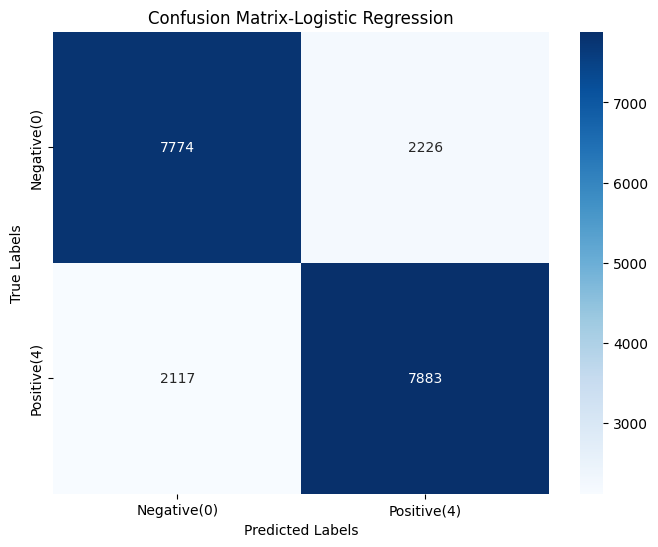

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Confusion matrix
cm=confusion_matrix(y_test,lr_test_preds)
# Visualize (Heatmap)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Negative(0)','Positive(4)'],yticklabels=['Negative(0)','Positive(4)'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix-Logistic Regression')
plt.show()

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
# Approach B : Generative (Naive Bayes)
nb_model=MultinomialNB()
nb_model.fit(X_train,y_train)
# Predictions
nb_train_preds=nb_model.predict(X_train)
nb_test_preds=nb_model.predict(X_test)
# Results Display
print("Naive bayes (Generative)")
print(f"Training Accuracy:{accuracy_score(y_train,nb_train_preds):.4f}")
print(f"Testing Accuracy:{accuracy_score(y_test,nb_test_preds):.4f}")
# Classification report
print("Classification Report")
print(classification_report(y_test,nb_test_preds))


Naive bayes (Generative)
Training Accuracy:0.8691
Testing Accuracy:0.7548
Classification Report
              precision    recall  f1-score   support

           0       0.72      0.82      0.77     10000
           4       0.80      0.69      0.74     10000

    accuracy                           0.75     20000
   macro avg       0.76      0.75      0.75     20000
weighted avg       0.76      0.75      0.75     20000



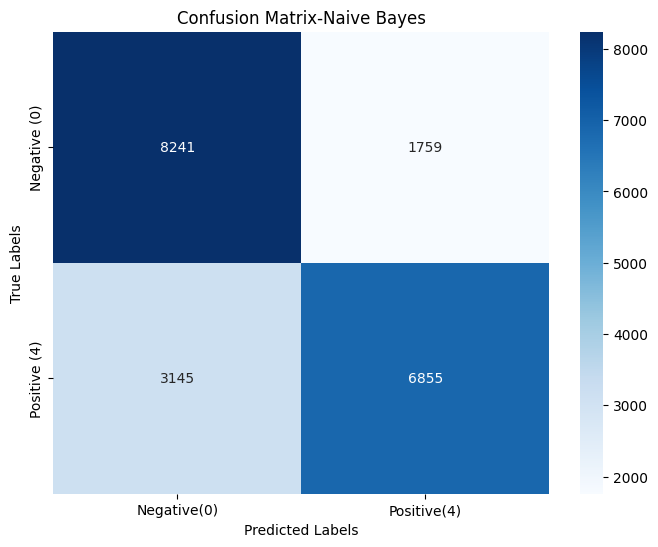

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Confusion matrix
cm=confusion_matrix(y_test,nb_test_preds)

# Visualize (heatmap)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Negative(0)','Positive(4)'],yticklabels=['Negative (0)','Positive (4)']
            )
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix-Naive Bayes')
plt.show()


Accuracy:

Logistic Regression performed batter on unseen (testing data) training accuracy is 0.8387 and testing accuracy is  0.7829 .But in case of Naive bayes training accuracy is 0.8691 but testing is 0.7548 indicates model get overfitting so winner model is logistic regression model learns in actual pattern not just memorize so it is generalzie on new data.

 Interpretability:

Logistic regression very interpretable we can see weight of each feature (word) if weight of a feature is positive it point out toward positive class.Naive Bayes works on probability calculate probability of each word helps to see (which words most frequently appeared in positive class)but it ignores relationships between words so sometime provide strange results.


Data Requirements:

Discriminative (Logistic) require more data for improvement of performance  so that draw class boundry (Positive or Negative) in a way accurately classified data.

Generative(Naive Bayes): require less data because only depends on counts and probability but face difficulty with complex data (twitter) because it has independence Assumption (consider words independent from each other)